In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Import Library

In [2]:
import os
import shutil
import random
import cv2
import time

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from sklearn.metrics import confusion_matrix

#Transformasi Data

In [6]:
path_dir = '/content/drive/MyDrive/Coding/Skripsi/Dataset/skenario_data_B'

In [7]:
names = []
nums = []
data = {'Nama Kelas':[], 'Jumlah Sample':[]}

for i in os.listdir(path_dir+'/train'):
  nums.append(len(os.listdir(path_dir+'/train/'+i)))
  names.append(i)

data['Nama Kelas']+=names
data['Jumlah Sample']+=nums

df = pd.DataFrame(data)
df

,Nama Kelas,Jumlah Sample
0,Healthy,192
1,Apple_Rust,192
2,Apple_Scab,192


<Axes: xlabel='Nama Kelas', ylabel='Jumlah Sample'>

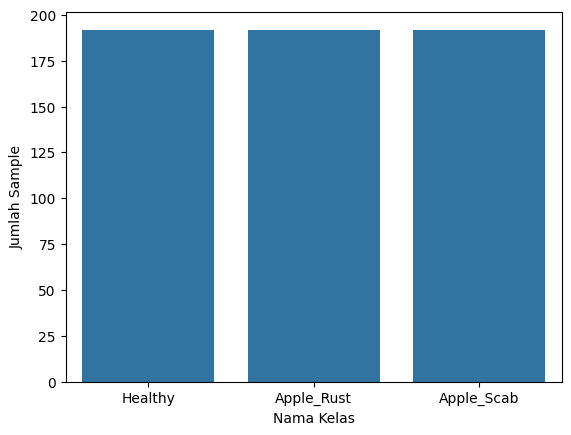

In [8]:
sns.barplot(x=df['Nama Kelas'],y=df['Jumlah Sample'])

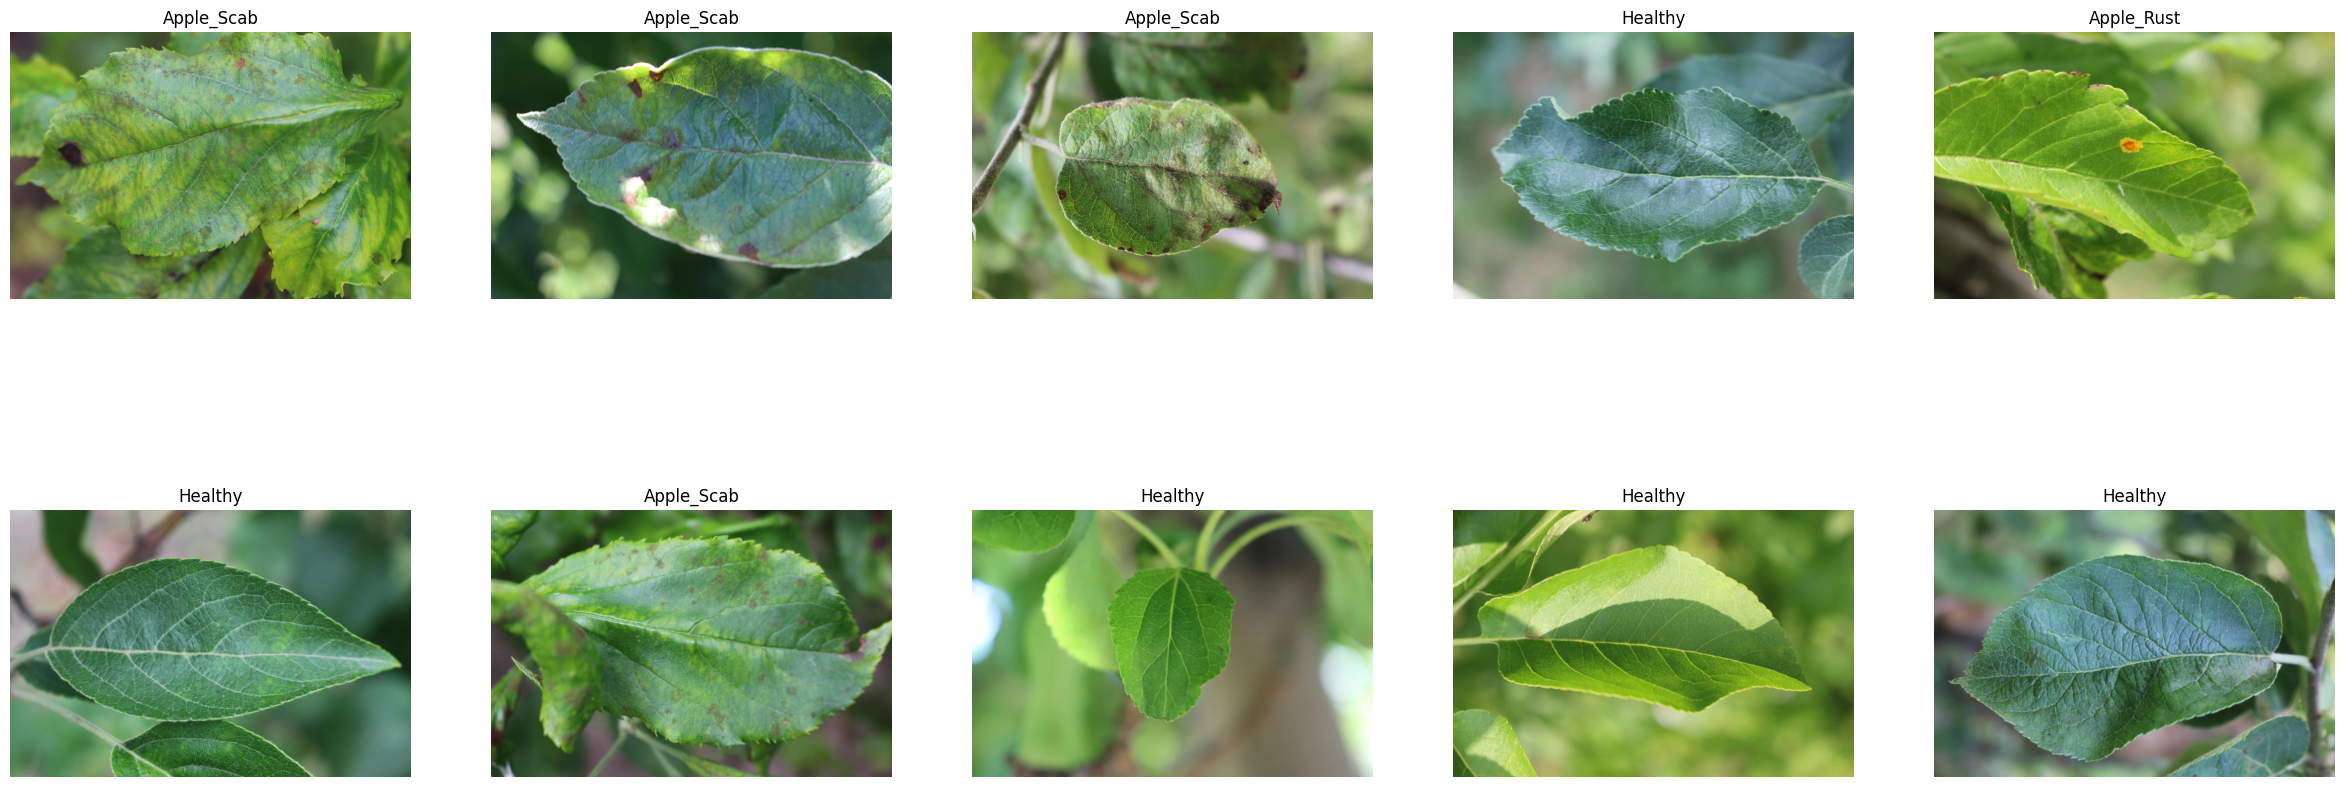

In [10]:
classes = os.listdir(path_dir+'/train')

plt.figure(figsize=(30,30))
for x in range(10):
  i = random.randint(0,2)
  images = os.listdir(path_dir+'/train'+'/'+classes[i])
  j = random.randint(0,100)
  image = cv2.imread(path_dir+'/train'+'/'+classes[i]+'/'+images[j])
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  ax = plt.subplot(5, 5, x + 1)
  plt.imshow(image)
  plt.title(classes[i])
  plt.axis("off")

plt.show()

In [11]:
data_generator = ImageDataGenerator(
    rescale=1./255,  # Normalisasi skala gambar
    rotation_range=180,  # Rotasi dalam rentang 180 derajat
    width_shift_range=0.2,  # Pergeseran horisontal sebesar 20% dari lebar gambar
    height_shift_range=0.2,  # Pergeseran vertikal sebesar 20% dari tinggi gambar
    zoom_range=[0.2, 1.8],  # Zoom antara 20% hingga 180%
    shear_range=0.2,  # Rotasi persegi panjang sebesar 20 derajat
    horizontal_flip=True,  # Membalikkan gambar secara horizontal
    vertical_flip=True,  # Membalikkan gambar secara vertikal
    brightness_range=[0.2, 1.8],  # Rentang perubahan kecerahan antara 20% hingga 120%
    fill_mode='nearest'  # Pengisian piksel yang hilang dengan piksel terdekat
)

dataval_generator = ImageDataGenerator(
    rescale=1./255
)

In [12]:
train_datagen = data_generator.flow_from_directory(
    path_dir+'/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_datagen = dataval_generator.flow_from_directory(
    path_dir+'/val',
    target_size=(224, 224),
    class_mode='categorical'
)

Found 576 images belonging to 3 classes.
Found 81 images belonging to 3 classes.


#Build Model

In [13]:
mobilenet = tf.keras.applications.mobilenet.MobileNet(input_shape=(224,224,3),
                                                      include_top=False,
                                                      weights='imagenet')
mobilenet.trainable = False

model = Sequential([
    mobilenet,
    GlobalAveragePooling2D(),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.25),
    Dense(3, activation="softmax", name="classification")
])

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [19]:
fname="/content/drive/MyDrive/Colab/Model/Model.AB5.025.256_RMSprop.keras"
checkpoint = ModelCheckpoint(fname, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
log_file = '/content/drive/MyDrive/Colab/Model/training_log_AB5_0,25_256_RMSprop.csv'
csv_logger = CSVLogger(log_file)
callbacks = [checkpoint, csv_logger]

In [20]:
from tensorflow.keras.optimizers import RMSprop
model.compile(optimizer=RMSprop(learning_rate=(0.0001)),
              loss='categorical_crossentropy',
              metrics=['accuracy',tf.keras.metrics.AUC()])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,492,035 (13.32 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [21]:
start_time = time.time()
history = model.fit(train_datagen,
                    validation_data=val_datagen,
                    epochs=100,
                    callbacks=callbacks,
                    verbose=1)
end_time = time.time()

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.5043 - auc_1: 0.6898 - loss: 1.0347
Epoch 1: val_accuracy improved from -inf to 0.77778, saving model to /content/drive/MyDrive/Colab/Model/Model.AB5.025.256_RMSprop.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 85s 5s/step - accuracy: 0.5070 - auc_1: 0.6926 - loss: 1.0298 - val_accuracy: 0.7778 - val_auc_1: 0.9313 - val_loss: 0.5906
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.6594 - auc_1: 0.8190 - loss: 0.8074
Epoch 2: val_accuracy improved from 0.77778 to 0.80247, saving model to /content/drive/MyDrive/Colab/Model/Model.AB5.025.256_RMSprop.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 965ms/step - accuracy: 0.6590 - auc_1: 0.8186 - loss: 0.8084 - val_accuracy: 0.8025 - val_auc_1: 0.9535 - val_loss: 0.4958
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.7154 - auc_1: 0.8681 - loss: 0.7019
Epoch 3: val_accuracy improved from 0.80247 to 0.86420, saving model to /content/drive/MyDrive/Colab/Model/Mode

In [22]:
training_time = end_time - start_time

m, s = divmod(training_time, 60)
h, m = divmod(m, 60)
training_time_format = "%d:%02d:%02d" % (h, m, s)

print("Waktu Pelatihan: %s" % training_time_format)

Waktu Pelatihan: 0:33:12


In [23]:
lab_dir = '/content/drive/MyDrive/Coding/Skripsi/Dataset/skenario_data_A'

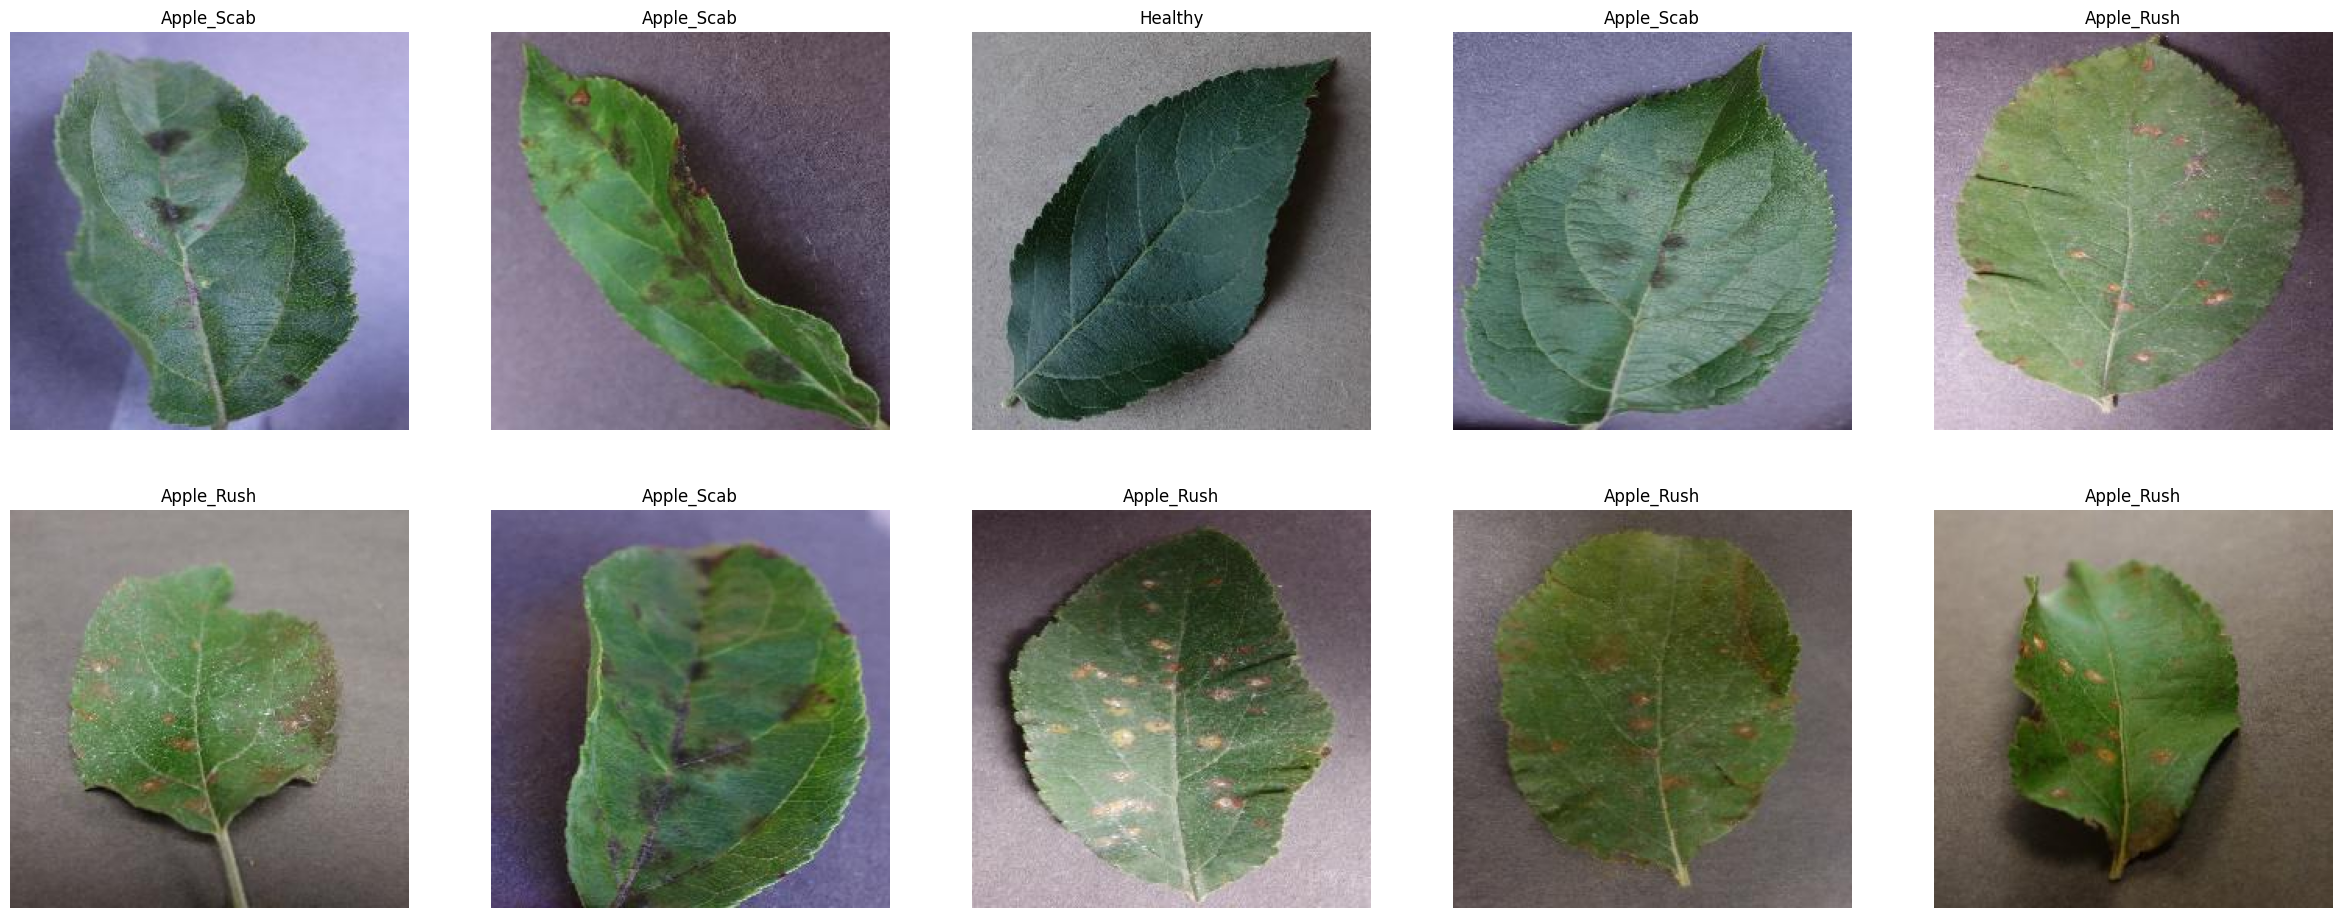

In [24]:
classes = os.listdir(lab_dir+'/train')

plt.figure(figsize=(30,30))
for x in range(10):
  i = random.randint(0,2)
  images = os.listdir(lab_dir+'/train'+'/'+classes[i])
  j = random.randint(0,100)
  image = cv2.imread(lab_dir+'/train'+'/'+classes[i]+'/'+images[j])
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  ax = plt.subplot(5, 5, x + 1)
  plt.imshow(image)
  plt.title(classes[i])
  plt.axis("off")

plt.show()

In [25]:
train_datagen_lab = data_generator.flow_from_directory(
    lab_dir+'/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_datagen_lab = dataval_generator.flow_from_directory(
    lab_dir+'/val',
    target_size=(224, 224),
    class_mode='categorical'
)

Found 576 images belonging to 3 classes.
Found 81 images belonging to 3 classes.


In [26]:
mobilenet.trainable = True

for layer in mobilenet.layers[:-10]:
  layer.trainable = False

model.compile(optimizer=RMSprop(learning_rate=(0.00001)),
              loss='categorical_crossentropy',
              metrics=['accuracy',tf.keras.metrics.AUC()])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,492,035 (13.32 MB)

 Trainable params: 1,851,395 (7.06 MB)

 Non-trainable params: 1,640,640 (6.26 MB)

In [27]:
fname_tuned="/content/drive/MyDrive/Colab/Model/Model.AB5.025.256_RMSprop_v2.keras"
checkpoint_tuned = ModelCheckpoint(fname_tuned, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
log_file = '/content/drive/MyDrive/Colab/Model/training_log_AB5_0,25_256_RMSprop_v2.csv'
csv_logger = CSVLogger(log_file)
callbacks_tuned = [checkpoint_tuned, csv_logger]

In [28]:
start_time = time.time()
history_tuned = model.fit(train_datagen_lab,
                    validation_data=val_datagen_lab,
                    epochs=100,
                    callbacks=callbacks_tuned,
                    verbose=1)
end_time = time.time()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.6954 - auc_2: 0.8464 - loss: 0.9820
Epoch 1: val_accuracy improved from -inf to 0.75309, saving model to /content/drive/MyDrive/Colab/Model/Model.AB5.025.256_RMSprop_v2.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.6956 - auc_2: 0.8472 - loss: 0.9763 - val_accuracy: 0.7531 - val_auc_2: 0.9084 - val_loss: 0.6717
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.7432 - auc_2: 0.8895 - loss: 0.7548
Epoch 2: val_accuracy did not improve from 0.75309
18/18 ━━━━━━━━━━━━━━━━━━━━ 62s 596ms/step - accuracy: 0.7427 - auc_2: 0.8898 - loss: 0.7529 - val_accuracy: 0.7407 - val_auc_2: 0.9088 - val_loss: 0.7202
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.7342 - auc_2: 0.8888 - loss: 0.7563
Epoch 3: val_accuracy did not improve from 0.75309
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 598ms/step - accuracy: 0.7360 - auc_2: 0.8898 - loss: 0.7512 - val_accuracy: 0.7407 - val_auc_2: 0.9131 - val_loss

In [29]:
training_time = end_time - start_time

m, s = divmod(training_time, 60)
h, m = divmod(m, 60)
training_time_format = "%d:%02d:%02d" % (h, m, s)

print("Waktu Pelatihan Kedua: %s" % training_time_format)

Waktu Pelatihan Kedua: 0:20:17


#Evaluasi Model

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 399ms/step - accuracy: 0.8478 - auc_2: 0.9397 - loss: 0.5204


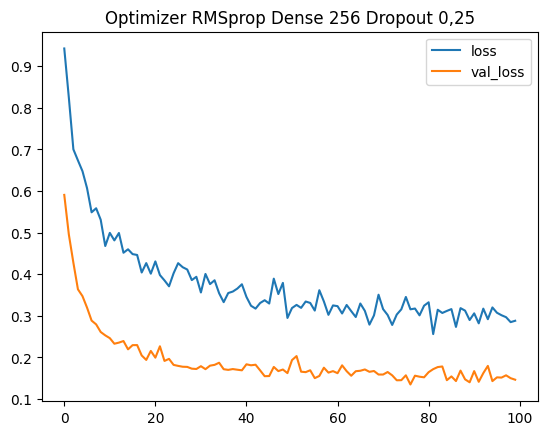

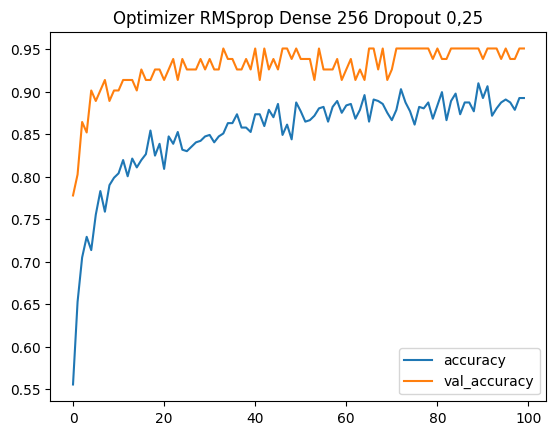

In [30]:
model.evaluate(val_datagen)

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'],loc='best')
plt.title('Optimizer RMSprop Dense 256 Dropout 0,25')
plt.show()
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy','val_accuracy'],loc='best')
plt.title('Optimizer RMSprop Dense 256 Dropout 0,25')
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 451ms/step - accuracy: 0.8595 - auc_2: 0.9295 - loss: 0.5666


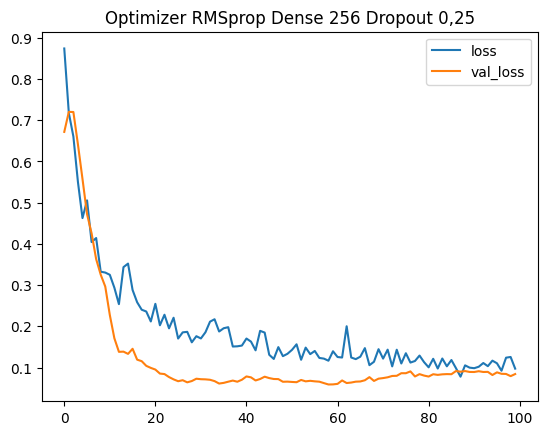

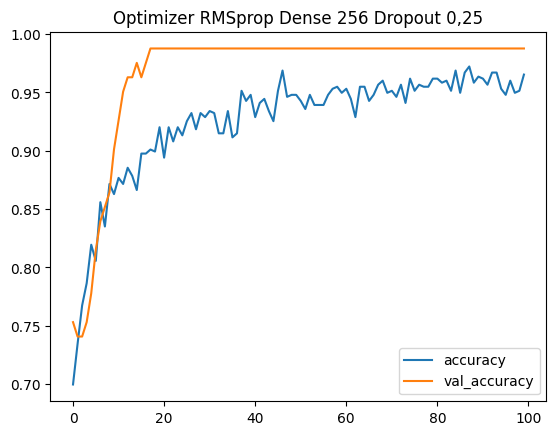

In [31]:
model.evaluate(val_datagen)

plt.figure()
plt.plot(history_tuned.history['loss'])
plt.plot(history_tuned.history['val_loss'])
plt.legend(['loss','val_loss'],loc='best')
plt.title('Optimizer RMSprop Dense 256 Dropout 0,25')
plt.show()
plt.figure()
plt.plot(history_tuned.history['accuracy'])
plt.plot(history_tuned.history['val_accuracy'])
plt.legend(['accuracy','val_accuracy'],loc='best')
plt.title('Optimizer RMSprop Dense 256 Dropout 0,25')
plt.show()

#Testing Model dengan Confusion Matrix

In [32]:
# Mendefinisikan path ke direktori gambar pengujian
test_dir = "/content/drive/MyDrive/Coding/Skripsi/Dataset/skenario_data_B/test"

# Membuat objek ImageDataGenerator untuk normalisasi data
test_datagen = ImageDataGenerator(rescale=1./255)

# Membuat generator data pengujian
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Ukuran gambar target
    class_mode='categorical',  # Mode kelas berdasarkan direktori
    shuffle=False  # Jangan mengacak urutan data
)


Found 168 images belonging to 3 classes.


6/6 ━━━━━━━━━━━━━━━━━━━━ 110s 21s/step


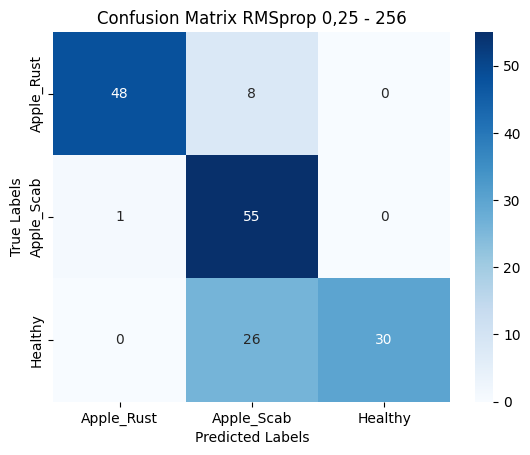

In [33]:
# Mendapatkan prediksi kelas dari model untuk data pengujian
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Mendapatkan label yang sebenarnya untuk data pengujian
y_true = test_generator.classes

# Menghitung matriks kebingungan
cm = confusion_matrix(y_true, y_pred_classes)

# Mendefinisikan label kelas
class_labels = test_generator.class_indices

# Membuat heatmap dari matriks kebingungan
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

# Menyesuaikan tampilan plot
plt.title('Confusion Matrix RMSprop 0,25 - 256')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Menampilkan plot
plt.show()


# Testing Tuned Model

In [34]:
# Mendefinisikan path ke direktori gambar pengujian
test_dir = "/content/drive/MyDrive/Coding/Skripsi/Dataset/skenario_data_A/test"

# Membuat objek ImageDataGenerator untuk normalisasi data
test_datagen = ImageDataGenerator(rescale=1./255)

# Membuat generator data pengujian
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Ukuran gambar target
    class_mode='categorical',  # Mode kelas berdasarkan direktori
    shuffle=False  # Jangan mengacak urutan data
)

Found 168 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 103s 21s/step


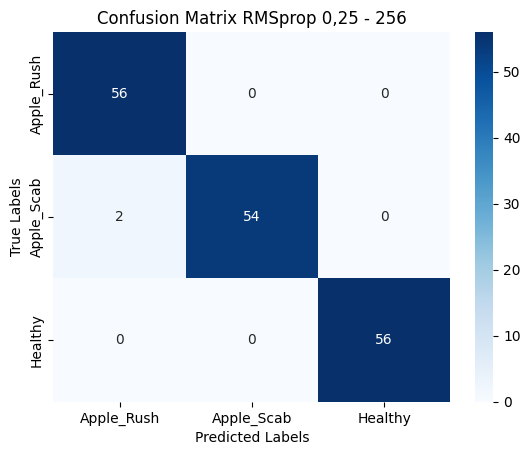

In [35]:
# Mendapatkan prediksi kelas dari model untuk data pengujian
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Mendapatkan label yang sebenarnya untuk data pengujian
y_true = test_generator.classes

# Menghitung matriks kebingungan
cm = confusion_matrix(y_true, y_pred_classes)

# Mendefinisikan label kelas
class_labels = test_generator.class_indices

# Membuat heatmap dari matriks kebingungan
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

# Menyesuaikan tampilan plot
plt.title('Confusion Matrix RMSprop 0,25 - 256')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Menampilkan plot
plt.show()